# Metrics for my 4 m
## Calculating Accuracy, Precision, Recall, and F1-Scores

## 1. Imports

In [13]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import label_binarize
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load label encoder

In [14]:
# Load label encoder to know class names
try:
    label_encoder = joblib.load("../models/symptom_encoder.pkl")
    class_names = label_encoder.classes_
    print(f" Class mapping: {dict(enumerate(class_names))}")
except:
    class_names = ['crackles', 'other', 'rhonchi', 'stridor', 'wheeze', 'wheeze_crackle']

# Define high-risk classes (for binary metrics)
high_risk_classes = ['stridor', 'wheeze']
high_risk_indices = [i for i, name in enumerate(class_names) if name in high_risk_classes]

def convert_to_binary(labels, high_risk_indices):
    # Convert multi-class labels to binary (1 if label is high-risk)
    if isinstance(labels[0], str):
        return np.array([1 if label in high_risk_classes else 0 for label in labels])
    else:
        return np.isin(labels, high_risk_indices).astype(int)

def get_binary_risk(proba, high_risk_indices):
    # Get binary risk score from multi-class probabilities
    if proba.ndim == 2:
        return np.sum(proba[:, high_risk_indices], axis=1)
    else:
        return proba  # Already binary

# Store results
results = []

 Class mapping: {0: 'crackles', 1: 'other', 2: 'rhonchi', 3: 'stridor', 4: 'wheeze', 5: 'wheeze_crackle'}


## 3. Model 1: ResNet-18 (Acoustic)

In [15]:
print("\n" + "="*60)
print("MODEL 1: ResNet-18 (Acoustic)")
print("="*60)

try:
    model1_proba = np.load("../../sound_data/model_data/model_1_test_probabilities.npy")
    model1_labels = np.load("../../sound_data/model_data/model_1_test_labels.npy")
    
    # Convert to binary
    y_true_1 = convert_to_binary(model1_labels, high_risk_indices)
    y_pred_1 = (get_binary_risk(model1_proba, high_risk_indices) > 0.5).astype(int)
    
    # Calculate metrics
    acc_1 = accuracy_score(y_true_1, y_pred_1)
    prec_1 = precision_score(y_true_1, y_pred_1)
    rec_1 = recall_score(y_true_1, y_pred_1)
    f1_1 = f1_score(y_true_1, y_pred_1)
    
    print(f" Predictions loaded: {model1_proba.shape}")
    print(f"   Labels: {np.unique(model1_labels)}")
    print(f"   Binary labels - 0: {np.sum(y_true_1==0)}, 1: {np.sum(y_true_1==1)}")
    print(f"\n Metrics:")
    print(f"   Accuracy:  {acc_1:.4f} ({acc_1*100:.2f}%)")
    print(f"   Precision: {prec_1:.4f} ({prec_1*100:.2f}%)")
    print(f"   Recall:    {rec_1:.4f} ({rec_1*100:.2f}%)")
    print(f"   F1-Score:  {f1_1:.4f}")
    
    results.append({
        'Model': 'ResNet-18 (Acoustic)',
        'Accuracy': acc_1,
        'Precision': prec_1,
        'Recall': rec_1,
        'F1-Score': f1_1,
        'Samples': len(y_true_1)
    })
    
except Exception as e:
    print(f" Error: {e}")


MODEL 1: ResNet-18 (Acoustic)
 Predictions loaded: (986, 6)
   Labels: [0 1 2 3 4 5]
   Binary labels - 0: 899, 1: 87

 Metrics:
   Accuracy:  0.8895 (88.95%)
   Precision: 0.1071 (10.71%)
   Recall:    0.0345 (3.45%)
   F1-Score:  0.0522


## 4. Model 2: XGBoost (Acoustic)

In [16]:
print("\n" + "="*60)
print("MODEL 2: XGBoost (Acoustic)")
print("="*60)

try:
    model2_proba = np.load("../../sound_data/model_data/model_2_test_probabilities.npy")
    model2_labels = np.load("../../sound_data/model_data/model_2_test_labels.npy")
    
    # Convert to binary
    y_true_2 = convert_to_binary(model2_labels, high_risk_indices)
    y_pred_2 = (get_binary_risk(model2_proba, high_risk_indices) > 0.5).astype(int)
    
    # Calculate metrics
    acc_2 = accuracy_score(y_true_2, y_pred_2)
    prec_2 = precision_score(y_true_2, y_pred_2)
    rec_2 = recall_score(y_true_2, y_pred_2)
    f1_2 = f1_score(y_true_2, y_pred_2)
    
    print(f" Predictions loaded: {model2_proba.shape}")
    print(f"   Labels: {np.unique(model2_labels)}")
    print(f"   Binary labels - 0: {np.sum(y_true_2==0)}, 1: {np.sum(y_true_2==1)}")
    print(f"\n Metrics:")
    print(f"   Accuracy:  {acc_2:.4f} ({acc_2*100:.2f}%)")
    print(f"   Precision: {prec_2:.4f} ({prec_2*100:.2f}%)")
    print(f"   Recall:    {rec_2:.4f} ({rec_2*100:.2f}%)")
    print(f"   F1-Score:  {f1_2:.4f}")
    
    results.append({
        'Model': 'XGBoost (Acoustic)',
        'Accuracy': acc_2,
        'Precision': prec_2,
        'Recall': rec_2,
        'F1-Score': f1_2,
        'Samples': len(y_true_2)
    })
    
except Exception as e:
    print(f"Error: {e}")


MODEL 2: XGBoost (Acoustic)
 Predictions loaded: (986, 6)
   Labels: [0 1 2 3 4 5]
   Binary labels - 0: 899, 1: 87

 Metrics:
   Accuracy:  0.9057 (90.57%)
   Precision: 0.0000 (0.00%)
   Recall:    0.0000 (0.00%)
   F1-Score:  0.0000


## 5. Model 3: XGBoost (Clinical)

In [17]:
print("\n" + "="*60)
print("MODEL 3: XGBoost (Clinical)")
print("="*60)

try:
    model3_proba = np.load("../../sound_data/model_data/model_3_test_proba.npy")
    model3_labels = np.load("../../sound_data/model_data/model_3_test_labels.npy")
    
    # These are already binary
    y_true_3 = model3_labels
    y_pred_3 = (model3_proba > 0.5).astype(int)
    
    # Calculate metrics
    acc_3 = accuracy_score(y_true_3, y_pred_3)
    prec_3 = precision_score(y_true_3, y_pred_3)
    rec_3 = recall_score(y_true_3, y_pred_3)
    f1_3 = f1_score(y_true_3, y_pred_3)
    
    print(f" Predictions loaded: {model3_proba.shape}")
    print(f"   Labels - 0: {np.sum(y_true_3==0)}, 1: {np.sum(y_true_3==1)}")
    print(f"\n Metrics:")
    print(f"   Accuracy:  {acc_3:.4f} ({acc_3*100:.2f}%)")
    print(f"   Precision: {prec_3:.4f} ({prec_3*100:.2f}%)")
    print(f"   Recall:    {rec_3:.4f} ({rec_3*100:.2f}%)")
    print(f"   F1-Score:  {f1_3:.4f}")
    
    results.append({
        'Model': 'XGBoost (Clinical)',
        'Accuracy': acc_3,
        'Precision': prec_3,
        'Recall': rec_3,
        'F1-Score': f1_3,
        'Samples': len(y_true_3)
    })
    
except Exception as e:
    print(f" Error: {e}")


MODEL 3: XGBoost (Clinical)
 Predictions loaded: (20000,)
   Labels - 0: 19525, 1: 475

 Metrics:
   Accuracy:  0.9762 (97.62%)
   Precision: 0.5000 (50.00%)
   Recall:    0.9032 (90.32%)
   F1-Score:  0.6437


## 6. Model 3: Logistic Regression (Clinical)

In [18]:
print("\n" + "="*60)
print("MODEL 4: Logistic Regression (Clinical)")
print("="*60)

try:
    model4_proba = np.load("../../sound_data/model_data/model_4_test_proba.npy")
    model4_labels = np.load("../../sound_data/model_data/model_4_test_labels.npy")
    
    # These are already binary
    y_true_4 = model4_labels
    y_pred_4 = (model4_proba > 0.5).astype(int)
    
    # Calculate metrics
    acc_4 = accuracy_score(y_true_4, y_pred_4)
    prec_4 = precision_score(y_true_4, y_pred_4)
    rec_4 = recall_score(y_true_4, y_pred_4)
    f1_4 = f1_score(y_true_4, y_pred_4)
    
    print(f" Predictions loaded: {model4_proba.shape}")
    print(f"   Labels - 0: {np.sum(y_true_4==0)}, 1: {np.sum(y_true_4==1)}")
    print(f"\n Metrics:")
    print(f"   Accuracy:  {acc_4:.4f} ({acc_4*100:.2f}%)")
    print(f"   Precision: {prec_4:.4f} ({prec_4*100:.2f}%)")
    print(f"   Recall:    {rec_4:.4f} ({rec_4*100:.2f}%)")
    print(f"   F1-Score:  {f1_4:.4f}")
    
    results.append({
        'Model': 'Logistic Regression (Clinical)',
        'Accuracy': acc_4,
        'Precision': prec_4,
        'Recall': rec_4,
        'F1-Score': f1_4,
        'Samples': len(y_true_4)
    })
    
except Exception as e:
    print(f" Error: {e}")


MODEL 4: Logistic Regression (Clinical)
 Predictions loaded: (20000,)
   Labels - 0: 19525, 1: 475

 Metrics:
   Accuracy:  0.9453 (94.53%)
   Precision: 0.2982 (29.82%)
   Recall:    0.9642 (96.42%)
   F1-Score:  0.4555


## 7. Metrics Summary

In [19]:
print("\n" + "="*60)
print(" COMPLETE METRICS SUMMARY")
print("="*60)

df_results = pd.DataFrame(results)
print("\n", df_results.to_string(index=False))

# Format as percentage for display
df_percent = df_results.copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    df_percent[col] = df_percent[col].apply(lambda x: f"{x*100:.2f}%")

print("\n" + "="*60)
print(" METRICS (Percentage Format)")
print("="*60)
print("\n", df_percent.to_string(index=False))

# Save to CSV
df_results.to_csv("../../reports/ab_models_metrics.csv", index=False)
print("\n Metrics saved to: reports/ab_models_metrics.csv")


 COMPLETE METRICS SUMMARY

                          Model  Accuracy  Precision   Recall  F1-Score  Samples
          ResNet-18 (Acoustic)  0.889452   0.107143 0.034483  0.052174      986
            XGBoost (Acoustic)  0.905680   0.000000 0.000000  0.000000      986
            XGBoost (Clinical)  0.976250   0.500000 0.903158  0.643661    20000
Logistic Regression (Clinical)  0.945250   0.298177 0.964211  0.455495    20000

 METRICS (Percentage Format)

                          Model Accuracy Precision Recall F1-Score  Samples
          ResNet-18 (Acoustic)   88.95%    10.71%  3.45%    5.22%      986
            XGBoost (Acoustic)   90.57%     0.00%  0.00%    0.00%      986
            XGBoost (Clinical)   97.62%    50.00% 90.32%   64.37%    20000
Logistic Regression (Clinical)   94.53%    29.82% 96.42%   45.55%    20000

 Metrics saved to: reports/ab_models_metrics.csv


## 8. Visualizations

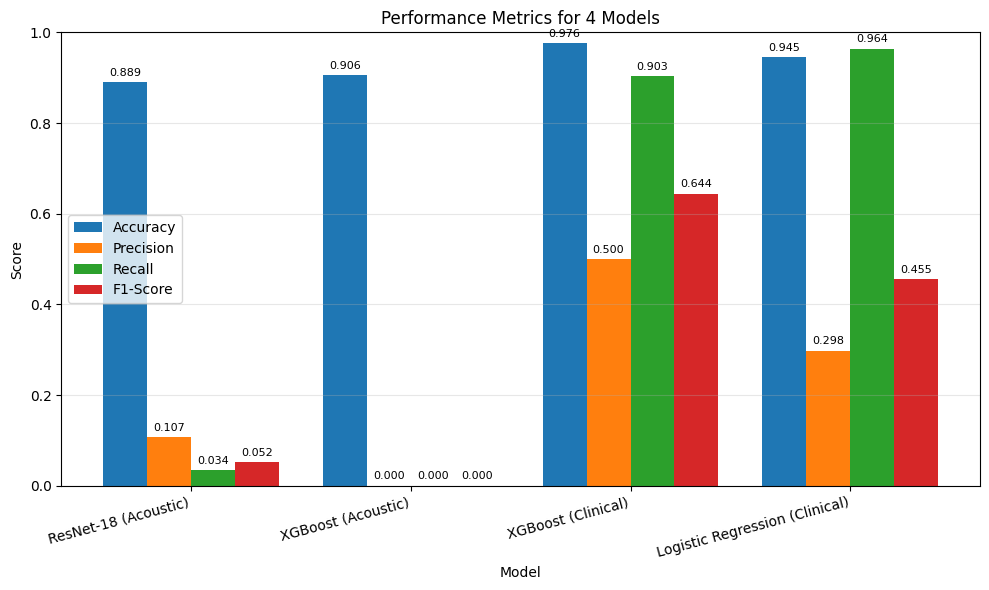


 Visualization saved to: reports/figures/ab_models_metrics.png


In [20]:
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(df_results))
width = 0.2

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
    values = df_results[metric].values
    bars = ax.bar(x + i*width - 0.3, values, width, label=metric, color=color)
    
    # Add value labels
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Performance Metrics for 4 Models')
ax.set_xticks(x)
ax.set_xticklabels(df_results['Model'], rotation=15, ha='right')
ax.legend()
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../../reports/figures/ab_models_metrics.png', dpi=150)
plt.show()

print("\n Visualization saved to: reports/figures/ab_models_metrics.png")